In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib notebook

In [105]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [5]:
target_mice = [803121]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 6 session assets


In [37]:
asset = assets[3]
print(asset.session_id)
gs = GlutamateSummary(asset.summary_mat)

803121_2025-11-01_19-00-21


### Plot raw data from a single segment of a session for one synapse

In [281]:
dmd = 2
synapse = 97

valid_trials = gs.valid_trials[1]
total_trials = gs.n_trials

In [282]:
traces = []

for trial in range(total_trials):
    if trial in valid_trials:
        trace = gs.get_traces(dmd=dmd,trial=trial)[:,synapse]
    else:
        shape = np.shape(gs.get_traces(dmd=dmd,trial=valid_trials[0])[:,synapse])
        trace = np.full(shape,np.nan)
    traces.append(trace)
    
traces = np.concatenate(traces)

In [283]:
epoch_path = os.path.join(asset.qc_dir,'behavior','imaging_epochs.csv')
image_epochs = pd.read_csv(epoch_path)
start_time = image_epochs['start_time']
end_time = image_epochs['end_time']

In [284]:
stim_path = os.path.join(asset.qc_dir,'glutamate','glutamate_extraction_qc.json')

with open(stim_path, "r") as f:
    im_json = json.load(f)

In [285]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

<IPython.core.display.Javascript object>


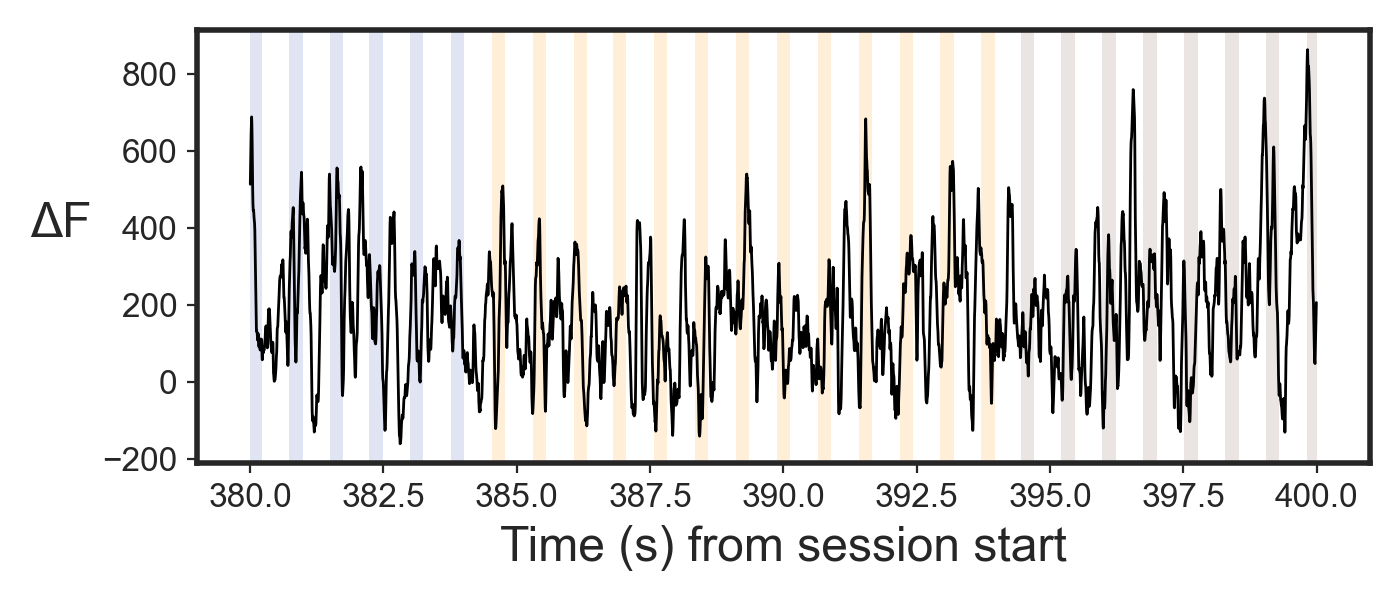

In [286]:
fig,ax=plt.subplots(figsize=(7,3))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

time = np.linspace(start_time,end_time,len(traces))

time_window = (380,400)

start,stop = np.where(time>=time_window[0])[0][0],np.where(time<=time_window[1])[0][-1]

rolling = pd.DataFrame(traces).rolling(20,min_periods = 1).mean()

ax.plot(time[start:stop],rolling[start:stop],color='k',lw=1)

# stimulus onsets from your qc json
image_onsets = im_json["per_dmd"][f"DMD{dmd}"]["stimulus_onsets_used_for_extraction"]["image_identity"]

# map image ids to your existing colors
image_ids = list(image_onsets.keys())
image_color_map = dict(zip(image_ids, im_colors[:len(image_ids)]))

win0, win1 = time_window

for image_id, onset_list in image_onsets.items():
    color = image_color_map[image_id]
    
    for onset in np.unique(np.asarray(onset_list, dtype=float)):
        span_start = onset
        span_end = onset + 0.25

        # only draw spans that overlap the plotted window
        if span_end >= win0 and span_start <= win1:
            ax.axvspan(
                max(span_start, win0),
                min(span_end, win1),
                color=color,
                alpha=0.5,
                lw=0,
                zorder=-1,
            )


ax.set_xlabel('Time (s) from session start')
ax.set_ylabel('\u0394F',rotation=0,labelpad=15)

for spine in ['top','bottom','left','right']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = 'example_untuned_trace'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi=300)

### Plot the response of a given synapse to a single trial

In [287]:
gs_trial_path = glob.glob(os.path.join(asset.derived_dir,'glutamate','glutamate_single_trial_df.npz'))[0]

In [288]:
trial_data = np.load(gs_trial_path,allow_pickle=True)['data'][0][f'DMD{dmd}']['image_identity']

In [289]:
im_names = list(trial_data.keys())
im_names

['stimuli\\images_B\\100075.tiff',
 'stimuli\\images_B\\216066.tiff',
 'stimuli\\images_B\\268048.tiff',
 'stimuli\\images_B\\41006.tiff',
 'stimuli\\images_B\\69022.tiff',
 'stimuli\\images_B\\McGill_stairs.tiff',
 'stimuli\\images_B\\imk01333.tiff']

<IPython.core.display.Javascript object>


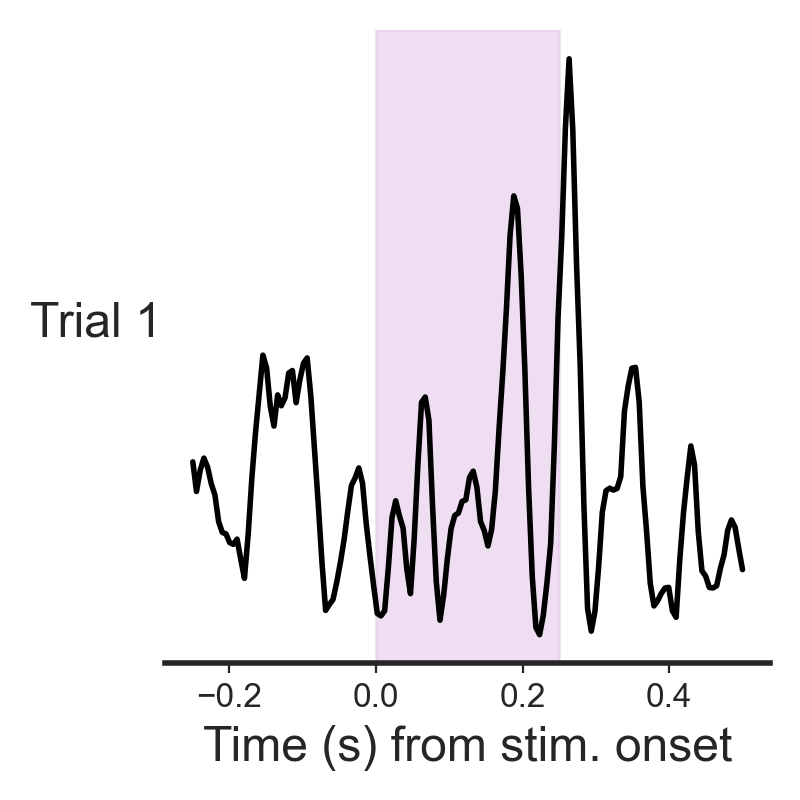

<IPython.core.display.Javascript object>


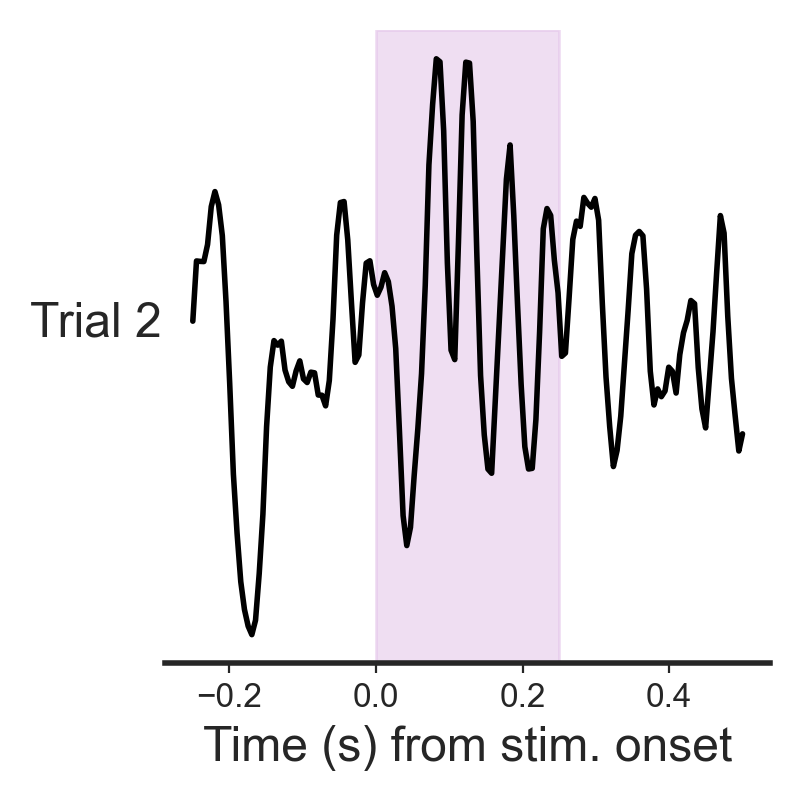

<IPython.core.display.Javascript object>


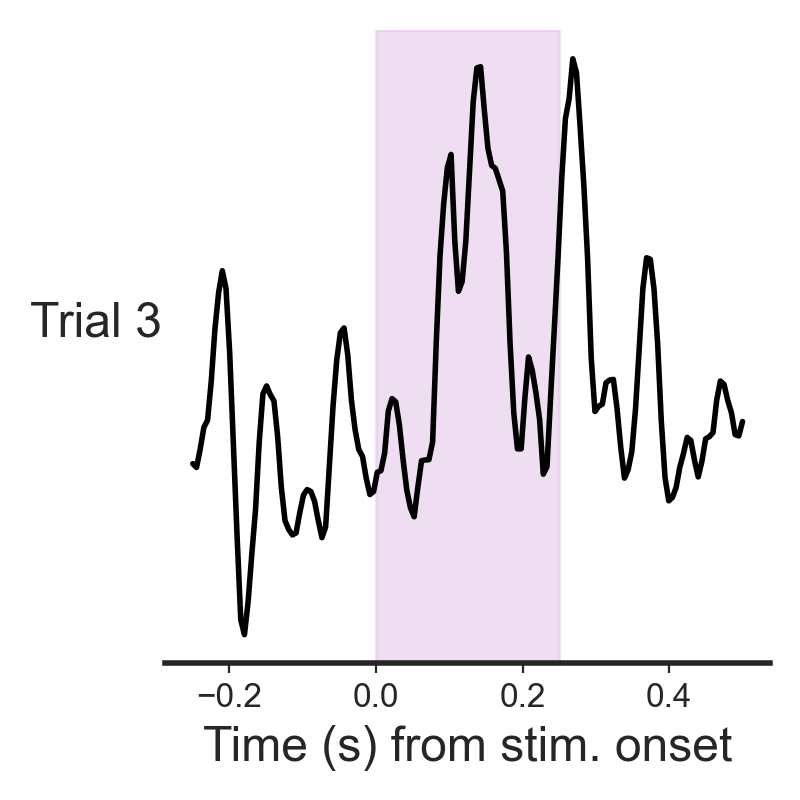

In [290]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]

trial_shape = synapse_trials.shape[1]

# tr= 250
fs = 200
for ii,tr in enumerate(np.arange(219,222)):
    fig,ax=plt.subplots(figsize=(4,4))

    sns.despine(left=True)
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    
    time = np.linspace(-0.25,0.5,trial_shape)

    rolling = pd.DataFrame(synapse_trials[tr]).rolling(5,min_periods=1).mean()

    ax.plot(time,rolling,color='k',lw=2)

    ax.set_yticks([])

    ax.set_xlabel('Time (s) from stim. onset')

    ax.spines['bottom'].set_linewidth(2)

    ax.axvspan(0.0,0.25,color=im_colors[i],alpha=0.5,zorder=0)
    ax.set_ylabel(f'Trial {ii+1}',rotation=0,labelpad=25)
    fig.tight_layout()
    filen = f'example_Trial{ii}'
    save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


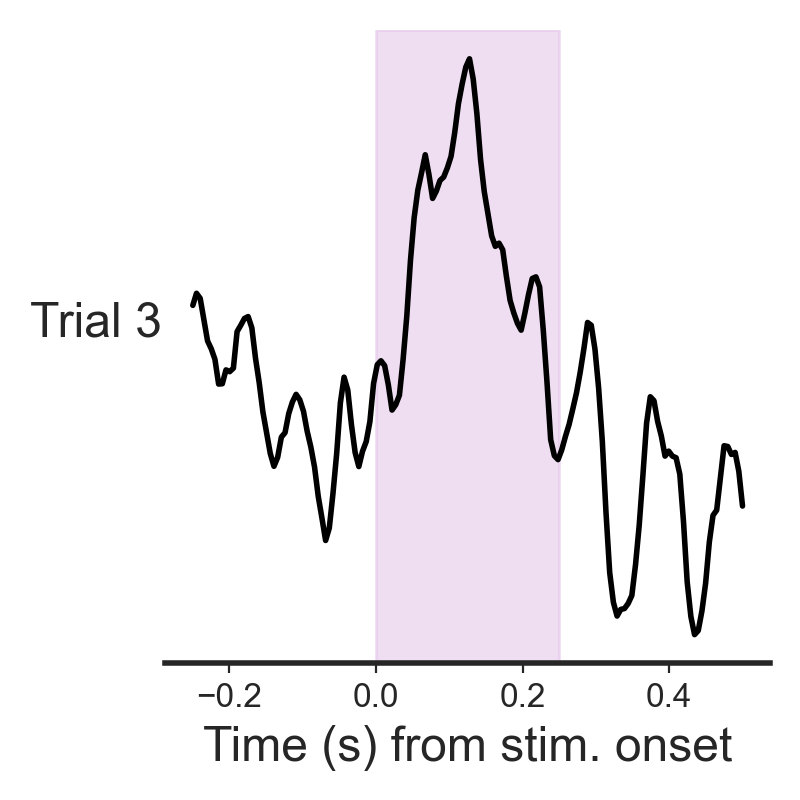

In [291]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]
trial_shape = synapse_trials.shape[1]

# tr= 250
fs = 200
fig,ax=plt.subplots(figsize=(4,4))

sns.despine(left=True)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

time = np.linspace(-0.25,0.5,trial_shape)

mean = np.nanmean(synapse_trials,axis=0)

rolling = pd.DataFrame(mean).rolling(5,min_periods=1).mean()

ax.plot(time,rolling,color='k',lw=2)

ax.set_yticks([])

ax.set_xlabel('Time (s) from stim. onset')

ax.spines['bottom'].set_linewidth(2)

ax.axvspan(0.0,0.25,color=im_colors[i],alpha=0.5,zorder=0)
ax.set_ylabel(f'Trial {ii+1}',rotation=0,labelpad=25)
fig.tight_layout()
filen = f'example_mean'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


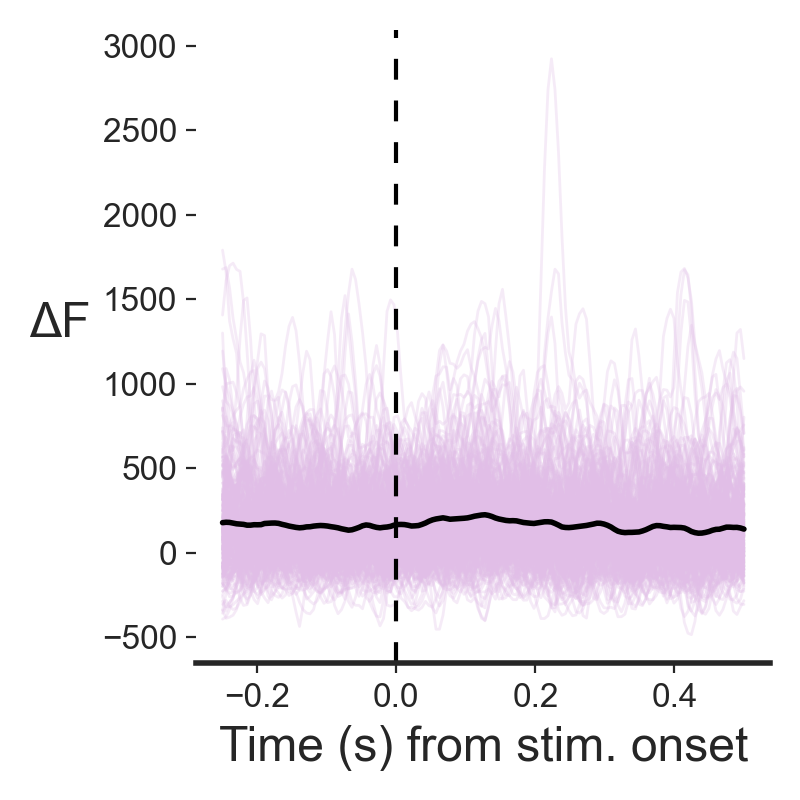

In [299]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]
trial_shape = synapse_trials.shape[1]
fig,ax=plt.subplots(figsize=(4,4))
time = np.linspace(-0.25,0.5,trial_shape)
# tr= 250
fs = 200
for ii,tr in enumerate(synapse_trials):

    sns.despine(left=True)
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

    rolling = pd.DataFrame(synapse_trials[ii]).rolling(5,min_periods=1).mean()

    ax.plot(time,rolling,color=im_colors[i],lw=1,alpha=0.3)

mean = np.nanmean(synapse_trials,axis=0)
rolling_mean = pd.DataFrame(mean).rolling(5,min_periods=1).mean()

ax.plot(time,rolling_mean,color='k',lw=2)

ax.set_ylabel('\u0394F',rotation=0,labelpad=15)
ax.set_xlabel('Time (s) from stim. onset')

ax.axvline(0.0,color='k',dashes=[5,5])

# ax.set_ylim(0,500)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
fig.tight_layout()
filen = f'example_im{i}'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

### Plot dF/F for a given synapses' mean responses

In [300]:
gs_dff_path = glob.glob(os.path.join(asset.derived_dir,'glutamate','glutamate_mean_dff_ls.npz'))[0]

In [301]:
dff_data = np.load(gs_dff_path,allow_pickle=True)['data'][0][f'DMD{dmd}']['image_identity']

In [302]:
im_names = list(dff_data.keys())
im_names

['stimuli\\images_B\\100075.tiff',
 'stimuli\\images_B\\216066.tiff',
 'stimuli\\images_B\\268048.tiff',
 'stimuli\\images_B\\41006.tiff',
 'stimuli\\images_B\\69022.tiff',
 'stimuli\\images_B\\McGill_stairs.tiff',
 'stimuli\\images_B\\imk01333.tiff']

<IPython.core.display.Javascript object>


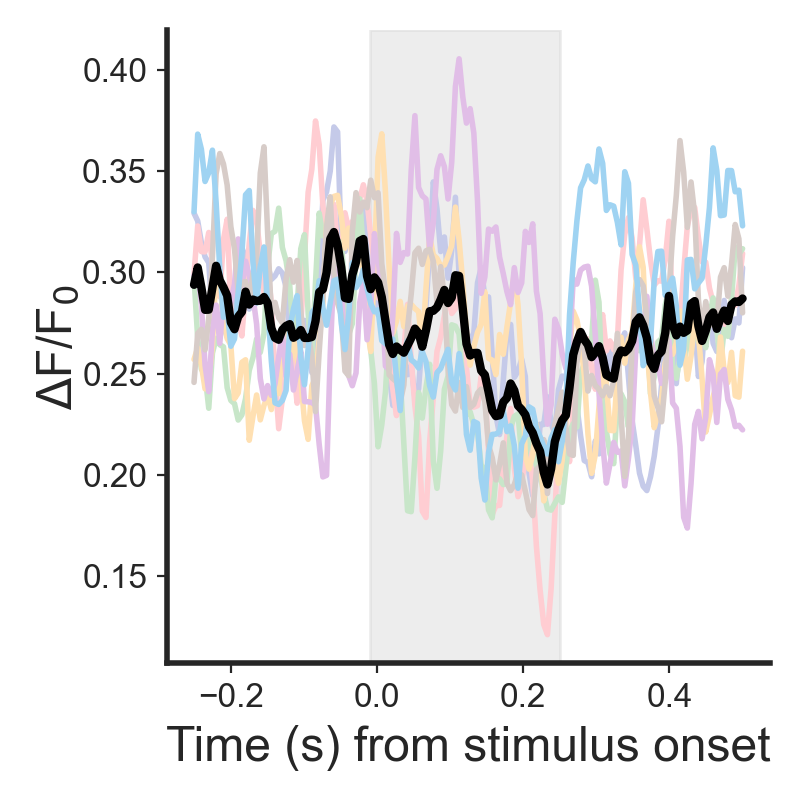

In [303]:
synapse = 97

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

trial_shape = dff_data[im_names[0]]['mean'][synapse].shape[0]
time = np.linspace(-0.25,0.5,trial_shape)

for i,im in enumerate(im_names):
    syn_data = dff_data[im]['mean'][synapse]
    im_rolling = pd.DataFrame(syn_data).rolling(1,min_periods=1).mean()
    ax.plot(time,im_rolling,color=im_colors[i],lw=2)
    
mean = np.mean([dff_data[im]['mean'][synapse] for im in im_names],axis=0)
rolling_mean  = pd.DataFrame(mean).rolling(1,min_periods=1).mean()

ax.plot(time,mean,color='k',lw=3)
ax.axvspan(-0.01,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('\u0394F/F$_{0}$',rotation=90,labelpad=0)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

In [255]:
mean

array([0.18537898, 0.19160573, 0.18557555, 0.18735957, 0.18069378,
       0.1880019 , 0.18487253, 0.18279001, 0.18038774, 0.18137657,
       0.18603162, 0.1912309 , 0.19080467, 0.18817033, 0.18418256,
       0.17538612, 0.1762316 , 0.17578248, 0.17423176, 0.17572668,
       0.17465553, 0.1721819 , 0.17420669, 0.17608151, 0.17562317,
       0.17592576, 0.1773885 , 0.17544384, 0.17264006, 0.16749641,
       0.16955801, 0.16846196, 0.16688421, 0.16749293, 0.17184098,
       0.17200514, 0.17484551, 0.17811247, 0.18970092, 0.19699957,
       0.20179264, 0.20142225, 0.19989688, 0.21045151, 0.21305363,
       0.22147841, 0.23206875, 0.23447894, 0.24649014, 0.25998003,
       0.2757955 , 0.2948413 , 0.30893883, 0.31581068, 0.31802974,
       0.31085439, 0.29998348, 0.29011893, 0.27951384, 0.27696935,
       0.26709143, 0.25439245, 0.25020701, 0.24993206, 0.24475794,
       0.24153335, 0.23251148, 0.21853628, 0.22442164, 0.22694644,
       0.23180513, 0.22737361, 0.21857287, 0.20845161, 0.19891